# 04 - Kumeler arasi yasam memnuniyeti
Kruskal-Wallis + yas/cinsiyet kontrollu regresyon. **Korelasyon, nedensellik degil.**

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from src.stats import ols
df = pd.read_csv("../data/processed/timeuse_clustered.csv")
note = " (SENTETIK VERI)" if df["synthetic"].iloc[0] else ""

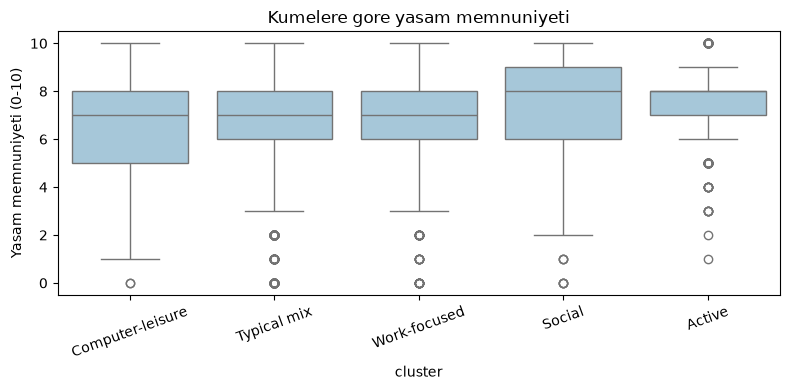

,mean,std,count
cluster,,,
Computer-leisure,6.57,1.97,222
Typical mix,7.08,2.13,5962
Work-focused,7.15,1.82,2847
Social,7.24,1.96,1011
Active,7.40,1.66,336


In [2]:
order = df.groupby("cluster")["life_sat"].mean().sort_values().index
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="cluster", y="life_sat", order=order, color="#9ecae1")
plt.xticks(rotation=20); plt.ylabel("Yasam memnuniyeti (0-10)")
plt.title("Kumelere gore yasam memnuniyeti" + note); plt.tight_layout()
plt.savefig("../figures/06_satisfaction_by_cluster.png", dpi=150); plt.show()
df.groupby("cluster")["life_sat"].agg(["mean", "std", "count"]).round(2).loc[order]

In [3]:
groups = [g["life_sat"].values for _, g in df.groupby("cluster")]
h, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis: H={h:.1f}, p={p:.2g}")

Kruskal-Wallis: H=27.1, p=1.9e-05


In [6]:
# Yas, cinsiyet ve hafta sonu kontrol edilerek kume farki (referans: alfabetik ilk kume)
d = df.copy()
d["cluster"] = d["cluster"].replace({"Typical mix": "0 Typical mix"})
d["sex"] = d["sex"].astype(str)
d["weekend"] = d["weekend"].astype(str)
res, r2 = ols(d, "life_sat", ["cluster", "sex", "weekend", "age"])
print(f"R2 = {r2:.3f}")
res.round(3)

R2 = 0.006


,coef,se,p
const,6.743,0.074,0.000
age,0.005,0.001,0.000
cluster_Active,0.408,0.114,0.000
cluster_Computer-leisure,-0.480,0.138,0.000
cluster_Social,0.182,0.069,0.008
cluster_Work-focused,0.122,0.050,0.015
sex_2,0.153,0.040,0.000
weekend_True,0.011,0.043,0.805
